In [1]:
from google.colab import files
uploaded = files.upload()

Saving deliveries.csv to deliveries.csv
Saving matches.csv to matches.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
matches = pd.read_csv('/content/matches.csv')
deliveries = pd.read_csv('/content/deliveries.csv')

In [4]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [7]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [8]:
matches.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [9]:
matches['winner'].fillna('No Result', inplace=True)

/tmp/ipykernel_651/1247128743.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['winner'].fillna('No Result', inplace=True)


In [10]:
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

In [12]:
import sqlite3

In [13]:
conn = sqlite3.connect('ipl.db')

In [18]:
deliveries.to_sql('deliveries', conn, if_exists='replace', index=False)

260920

In [14]:
matches.to_sql('matches', conn, if_exists='replace', index=False)

1095

In [15]:
query = """
SELECT winner, COUNT(*) as wins
FROM matches
GROUP BY winner
ORDER BY wins DESC
"""

team_wins = pd.read_sql(query, conn)

team_wins

,winner,wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bangalore,116
4,Rajasthan Royals,112
5,Sunrisers Hyderabad,88
6,Kings XI Punjab,88
7,Delhi Daredevils,67
8,Delhi Capitals,48
9,Deccan Chargers,29


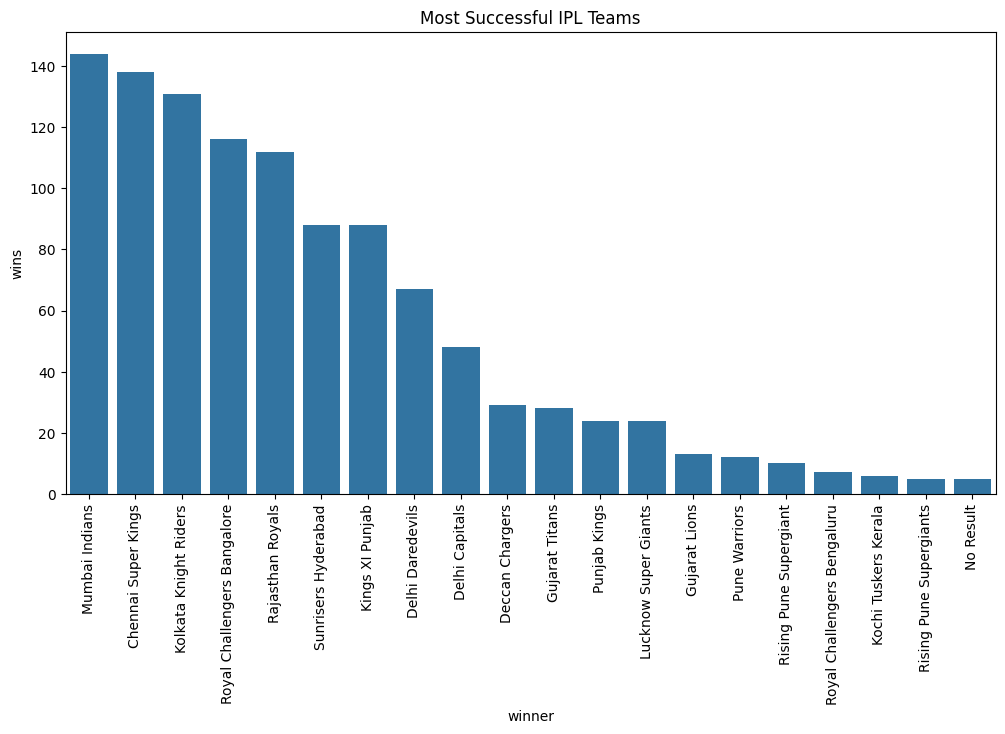

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(x='winner', y='wins', data=team_wins)

plt.xticks(rotation=90)

plt.title("Most Successful IPL Teams")

plt.show()

In [19]:
query = """
SELECT batter, SUM(batsman_runs) as total_runs
FROM deliveries
GROUP BY batter
ORDER BY total_runs DESC
LIMIT 10
"""

top_batsmen = pd.read_sql(query, conn)

top_batsmen

,batter,total_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


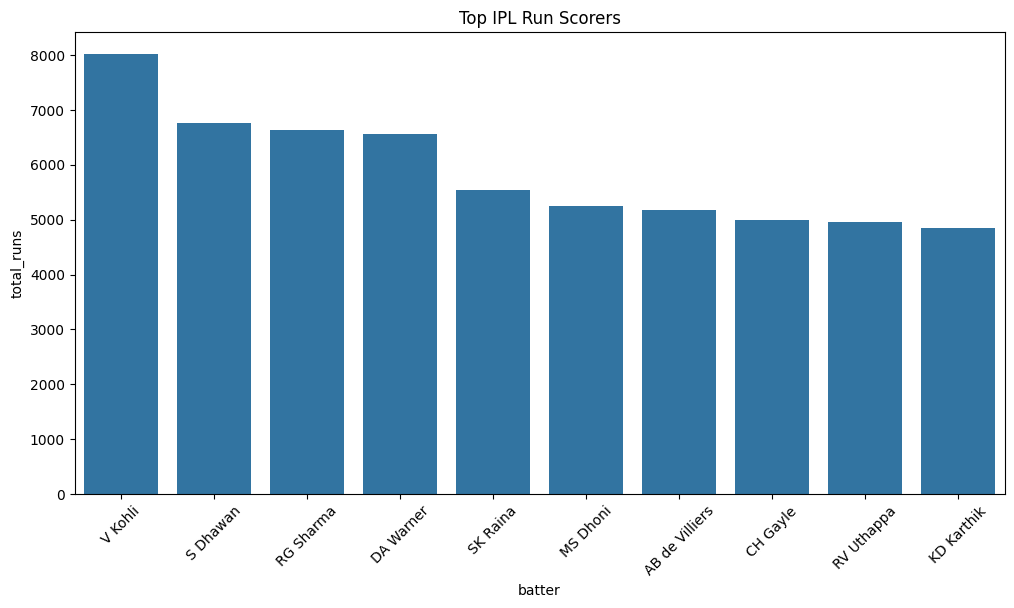

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(x='batter', y='total_runs', data=top_batsmen)

plt.xticks(rotation=45)

plt.title("Top IPL Run Scorers")

plt.show()

In [21]:
query = """
SELECT bowler, COUNT(*) as wickets
FROM deliveries
WHERE is_wicket = 1
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 10
"""

top_bowlers = pd.read_sql(query, conn)

top_bowlers

,bowler,wickets
0,YS Chahal,213
1,DJ Bravo,207
2,PP Chawla,201
3,SP Narine,200
4,R Ashwin,198
5,B Kumar,195
6,SL Malinga,188
7,A Mishra,183
8,JJ Bumrah,182
9,RA Jadeja,169


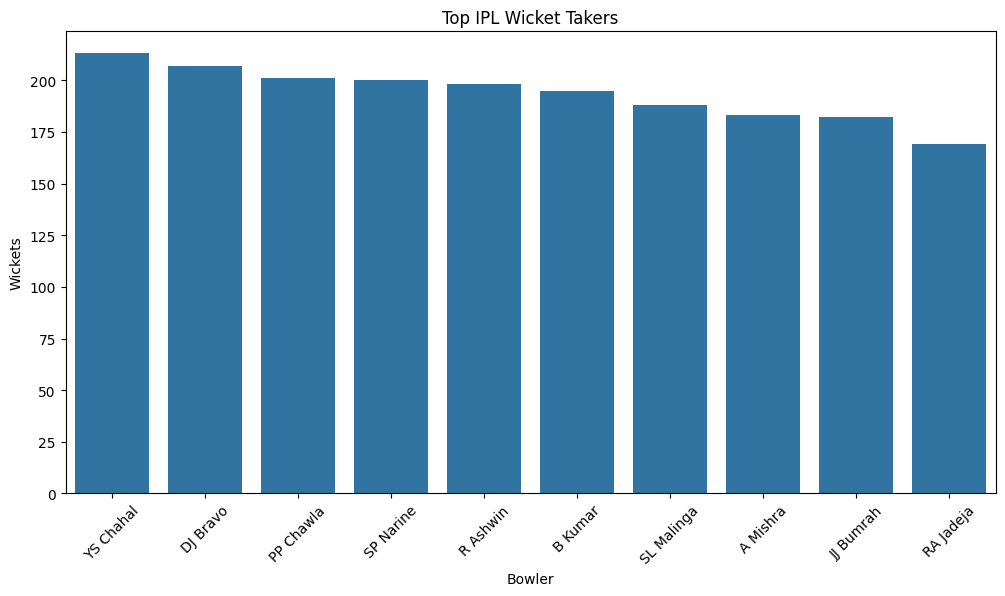

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='bowler',
    y='wickets',
    data=top_bowlers
)

plt.xticks(rotation=45)

plt.title("Top IPL Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

plt.show()

In [25]:
query = """
SELECT venue, COUNT(*) as total_matches
FROM matches
GROUP BY venue
ORDER BY total_matches DESC
LIMIT 10
"""

venue_analysis = pd.read_sql(query, conn)

venue_analysis

,venue,total_matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Rajiv Gandhi International Stadium, Uppal",49
5,"MA Chidambaram Stadium, Chepauk",48
6,Sawai Mansingh Stadium,47
7,Dubai International Cricket Stadium,46
8,"Wankhede Stadium, Mumbai",45
9,"Punjab Cricket Association Stadium, Mohali",35


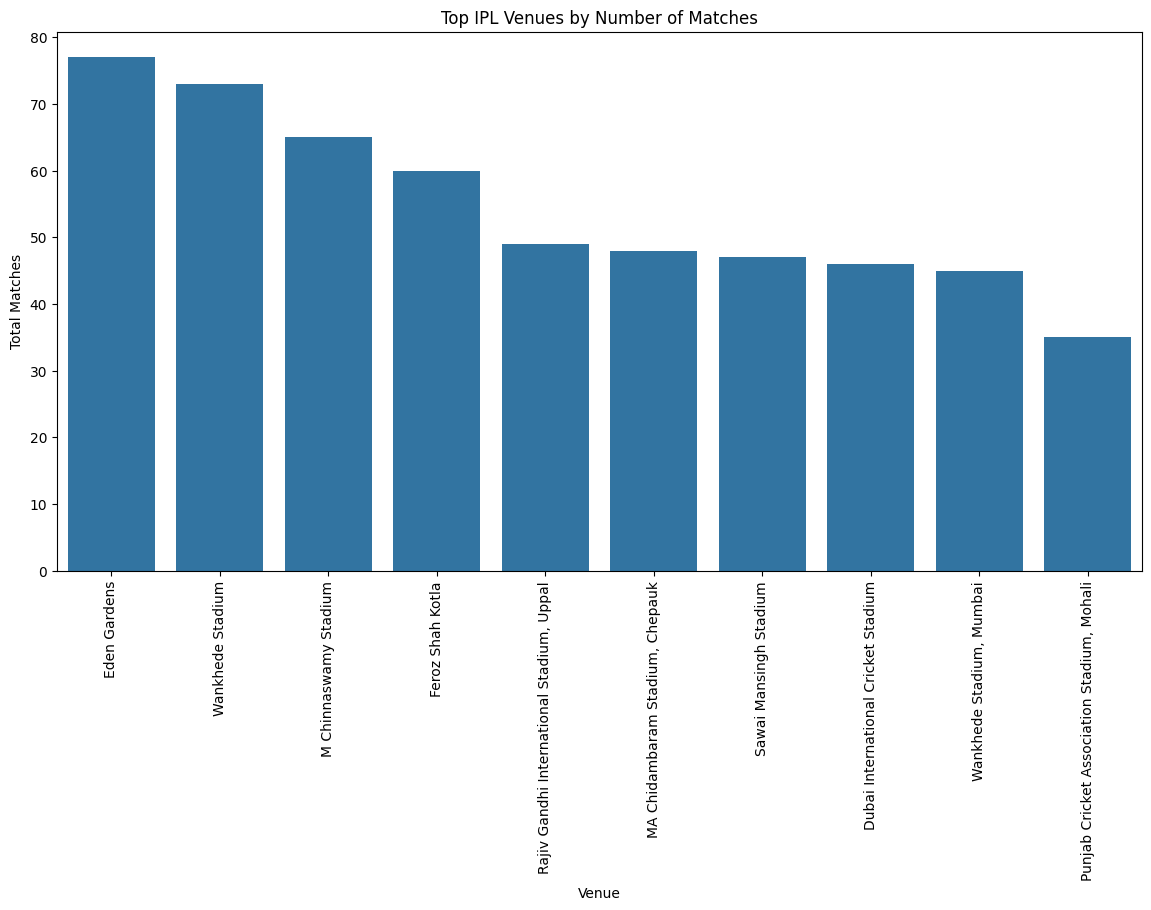

In [28]:
plt.figure(figsize=(14,7))

sns.barplot(
    x='venue',
    y='total_matches',
    data=venue_analysis
)

plt.xticks(rotation=90)

plt.title("Top IPL Venues by Number of Matches")
plt.xlabel("Venue")
plt.ylabel("Total Matches")

plt.show()

In [29]:
query = """
SELECT COUNT(*) as toss_match_win
FROM matches
WHERE toss_winner = winner
"""

pd.read_sql(query, conn)

,toss_match_win
0,554


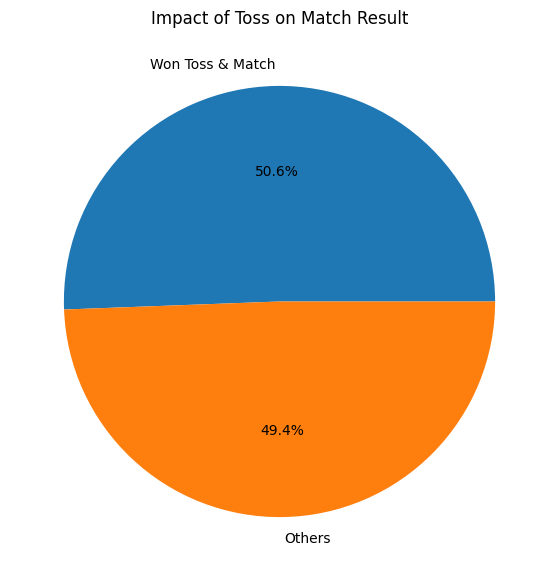

In [30]:
toss_data = matches[matches['toss_winner'] == matches['winner']]

labels = ['Won Toss & Match', 'Others']

sizes = [
    len(toss_data),
    len(matches) - len(toss_data)
]

plt.figure(figsize=(7,7))

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("Impact of Toss on Match Result")

plt.show()

In [31]:
query = """
SELECT player_of_match, COUNT(*) as awards
FROM matches
GROUP BY player_of_match
ORDER BY awards DESC
LIMIT 10
"""

top_players = pd.read_sql(query, conn)

top_players

,player_of_match,awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,V Kohli,18
4,DA Warner,18
5,MS Dhoni,17
6,YK Pathan,16
7,SR Watson,16
8,RA Jadeja,16
9,SP Narine,15


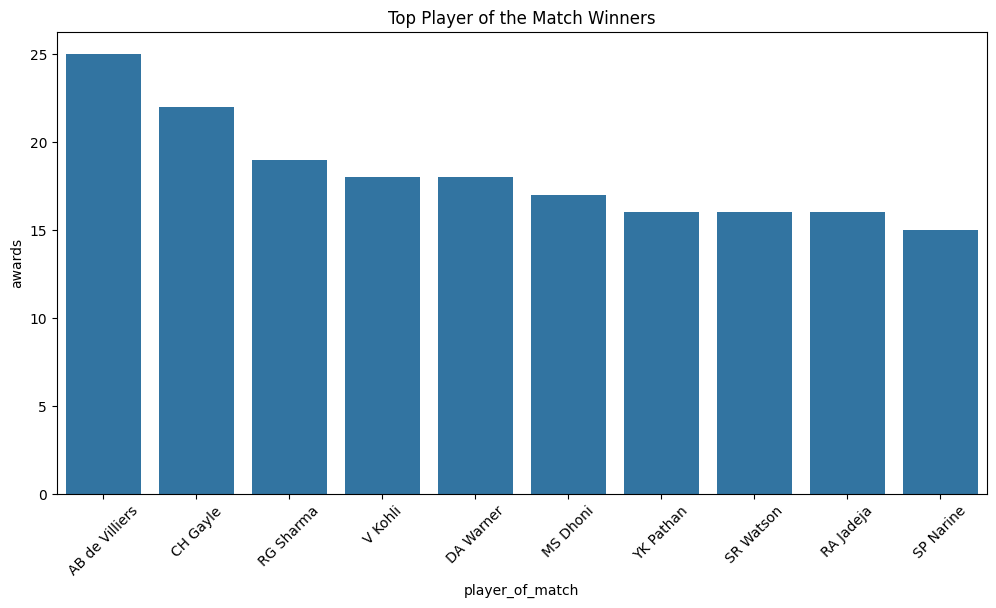

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='player_of_match',
    y='awards',
    data=top_players
)

plt.xticks(rotation=45)

plt.title("Top Player of the Match Winners")

plt.show()